# LeetCode #1108: IP Address to CIDR

https://leetcode.com/problems/ip-address-to-cidr/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (enumerate IPs)** | $O(n)$ | $O(n)$ |
| **Greedy Largest Aligned Block** ★ | $O(\log n)$ | $O(\log n)$ |

---

## Understanding the Methods

### Brute Force (enumerate IPs)
List every IP in the range individually and convert each to a /32 CIDR. Uses $O(n)$ blocks for $n$ addresses — completely impractical for large ranges.

### Optimal: Greedy Largest Aligned Block ★
At each step, find the largest power-of-two-aligned CIDR block that (a) starts at the current IP and (b) does not exceed the remaining count. The block size is `min(lowest_set_bit(ip), largest_power_of_two_≤_remaining)`. Convert the IP to a 32-bit integer for bit arithmetic, then back to dotted notation for output.

**Why this is better than Brute Force:** A greedy block selection produces at most $O(\log n)$ CIDR entries — compared to $O(n)$ for enumerating individual IPs — by packing addresses into the largest valid aligned blocks.

**Constraints:**
* `address` is a valid IPv4 address
* `1 <= n <= 10^6`

## Solutions

### C#

In [ ]:
public IList<string> IpToCidr(string ip, int n) {
    // Convert dotted IP string to a 32-bit integer for bit manipulation
    long addr = 0;
    foreach (string part in ip.Split('.')) {
        addr = addr * 256 + long.Parse(part);
    }

    var result = new List<string>();
    while (n > 0) {
        // Lowest set bit of addr gives the alignment constraint
        long lowBit = addr & (-addr);
        // Largest power of two not exceeding the remaining count
        long maxBlock = 1;
        while (maxBlock * 2 <= n && maxBlock * 2 <= lowBit) maxBlock *= 2;

        // Compute the CIDR prefix length from the block size
        int prefix = 32 - (int)Math.Log2(maxBlock);
        result.Add(LongToIp(addr) + "/" + prefix);
        addr += maxBlock;
        n -= (int)maxBlock;
    }
    return result;
}

private string LongToIp(long addr) {
    // Convert 32-bit integer back to dotted-decimal notation
    return string.Join(".", new long[] {
        (addr >> 24) & 255, (addr >> 16) & 255, (addr >> 8) & 255, addr & 255
    });
}

### Python

In [ ]:
import socket
import struct

def ipToCidr(self, ip: str, n: int) -> list[str]:
    # Convert IP to integer for bit manipulation
    addr = struct.unpack('!I', socket.inet_aton(ip))[0]
    result = []
    while n > 0:
        # Alignment constraint: lowest set bit of the current address
        low_bit = addr & (-addr) if addr else (1 << 32)
        # Take the largest power-of-two block that fits within the alignment and remainder
        max_block = 1
        while max_block * 2 <= n and max_block * 2 <= low_bit:
            max_block *= 2
        prefix = 32 - int(max_block).bit_length() + 1
        result.append(socket.inet_ntoa(struct.pack('!I', addr)) + f'/{prefix}')
        addr += max_block
        n -= max_block
    return result

### Go

In [ ]:
import (
    "fmt"
    "math/bits"
    "strconv"
    "strings"
)

func ipToCidr(ip string, n int) []string {
    // Parse dotted IP into a 32-bit unsigned integer
    parts := strings.Split(ip, ".")
    var addr uint32
    for _, p := range parts {
        v, _ := strconv.Atoi(p)
        addr = addr*256 + uint32(v)
    }
    var result []string
    for n > 0 {
        // Lowest set bit determines the alignment of the current block
        lowBit := addr & (^addr + 1)
        maxBlock := uint32(1)
        for maxBlock*2 <= uint32(n) && maxBlock*2 <= lowBit {
            maxBlock *= 2
        }
        // Prefix length is determined by how large the block is
        prefix := 32 - bits.Len32(maxBlock) + 1
        result = append(result, fmt.Sprintf("%d.%d.%d.%d/%d",
            addr>>24, (addr>>16)&255, (addr>>8)&255, addr&255, prefix))
        addr += maxBlock
        n -= int(maxBlock)
    }
    return result
}

### Rust

In [ ]:
pub fn ip_to_cidr(ip: String, n: i32) -> Vec<String> {
    // Parse the IP string into a u32 for bit arithmetic
    let mut addr: u32 = ip.split('.')
        .fold(0u32, |a, p| a * 256 + p.parse::<u32>().unwrap());
    let mut remaining = n as u32;
    let mut result = Vec::new();
    while remaining > 0 {
        // Alignment limit: lowest set bit of current address
        let low_bit = if addr == 0 { 1u32 << 31 } else { addr & addr.wrapping_neg() };
        let mut max_block = 1u32;
        while max_block * 2 <= remaining && max_block * 2 <= low_bit {
            max_block *= 2;
        }
        // Prefix = 32 minus the trailing zeros in the block size
        let prefix = 32 - max_block.trailing_zeros();
        result.push(format!("{}.{}.{}.{}/{}",
            addr >> 24, (addr >> 16) & 255, (addr >> 8) & 255, addr & 255, prefix));
        addr = addr.wrapping_add(max_block);
        remaining -= max_block;
    }
    result
}

## Example Scenarios

**1. Common Case**
**Input:** ip = "255.0.0.7", n = 10
addr = 0xFF000007. Low bit = 1 (bit 0 set) → maxBlock=1 → /32, then addr=...08; low bit=8 → maxBlock=8 ≤ 9 → /29; remaining=1 → /32. Result: **["255.0.0.7/32", "255.0.0.8/29", "255.0.0.15/32"]** — 3 CIDR blocks covering exactly 10 IPs.

**2. Slightly Complex**
**Input:** ip = "192.168.1.0", n = 16
addr ends in .0 → lowest set bit = 256 (byte boundary). maxBlock = min(16, 256) = 16 → /28. One CIDR block covers all 16 addresses. Result: **["192.168.1.0/28"]**.

**3. Edge Case: Time Factor**
**Input:** ip = "0.0.0.1", n = 1000000
addr = 1 → lowest bit = 1 → start with /32; then addr=2 → bit=2 → /31; grows quickly. Each step at least doubles, so only $O(\log 10^6) \approx 20$ blocks are produced. $O(\log n)$ iterations total.

**4. Edge Case: Space Factor**
**Input:** ip = "128.0.0.0", n = 1
Covers exactly 1 IP: **["128.0.0.0/32"]**. Output list has 1 entry, minimum space.

**5. Almost-Impossible but Plausible**
**Input:** ip = "255.255.255.255", n = 1
Maximum IP address (all bits set). Lowest set bit = 1 → maxBlock=1 → /32. Result: **["255.255.255.255/32"]**. addr wraps to 0 after adding 1 but remaining is already 0, so the loop exits cleanly.

### Infographic

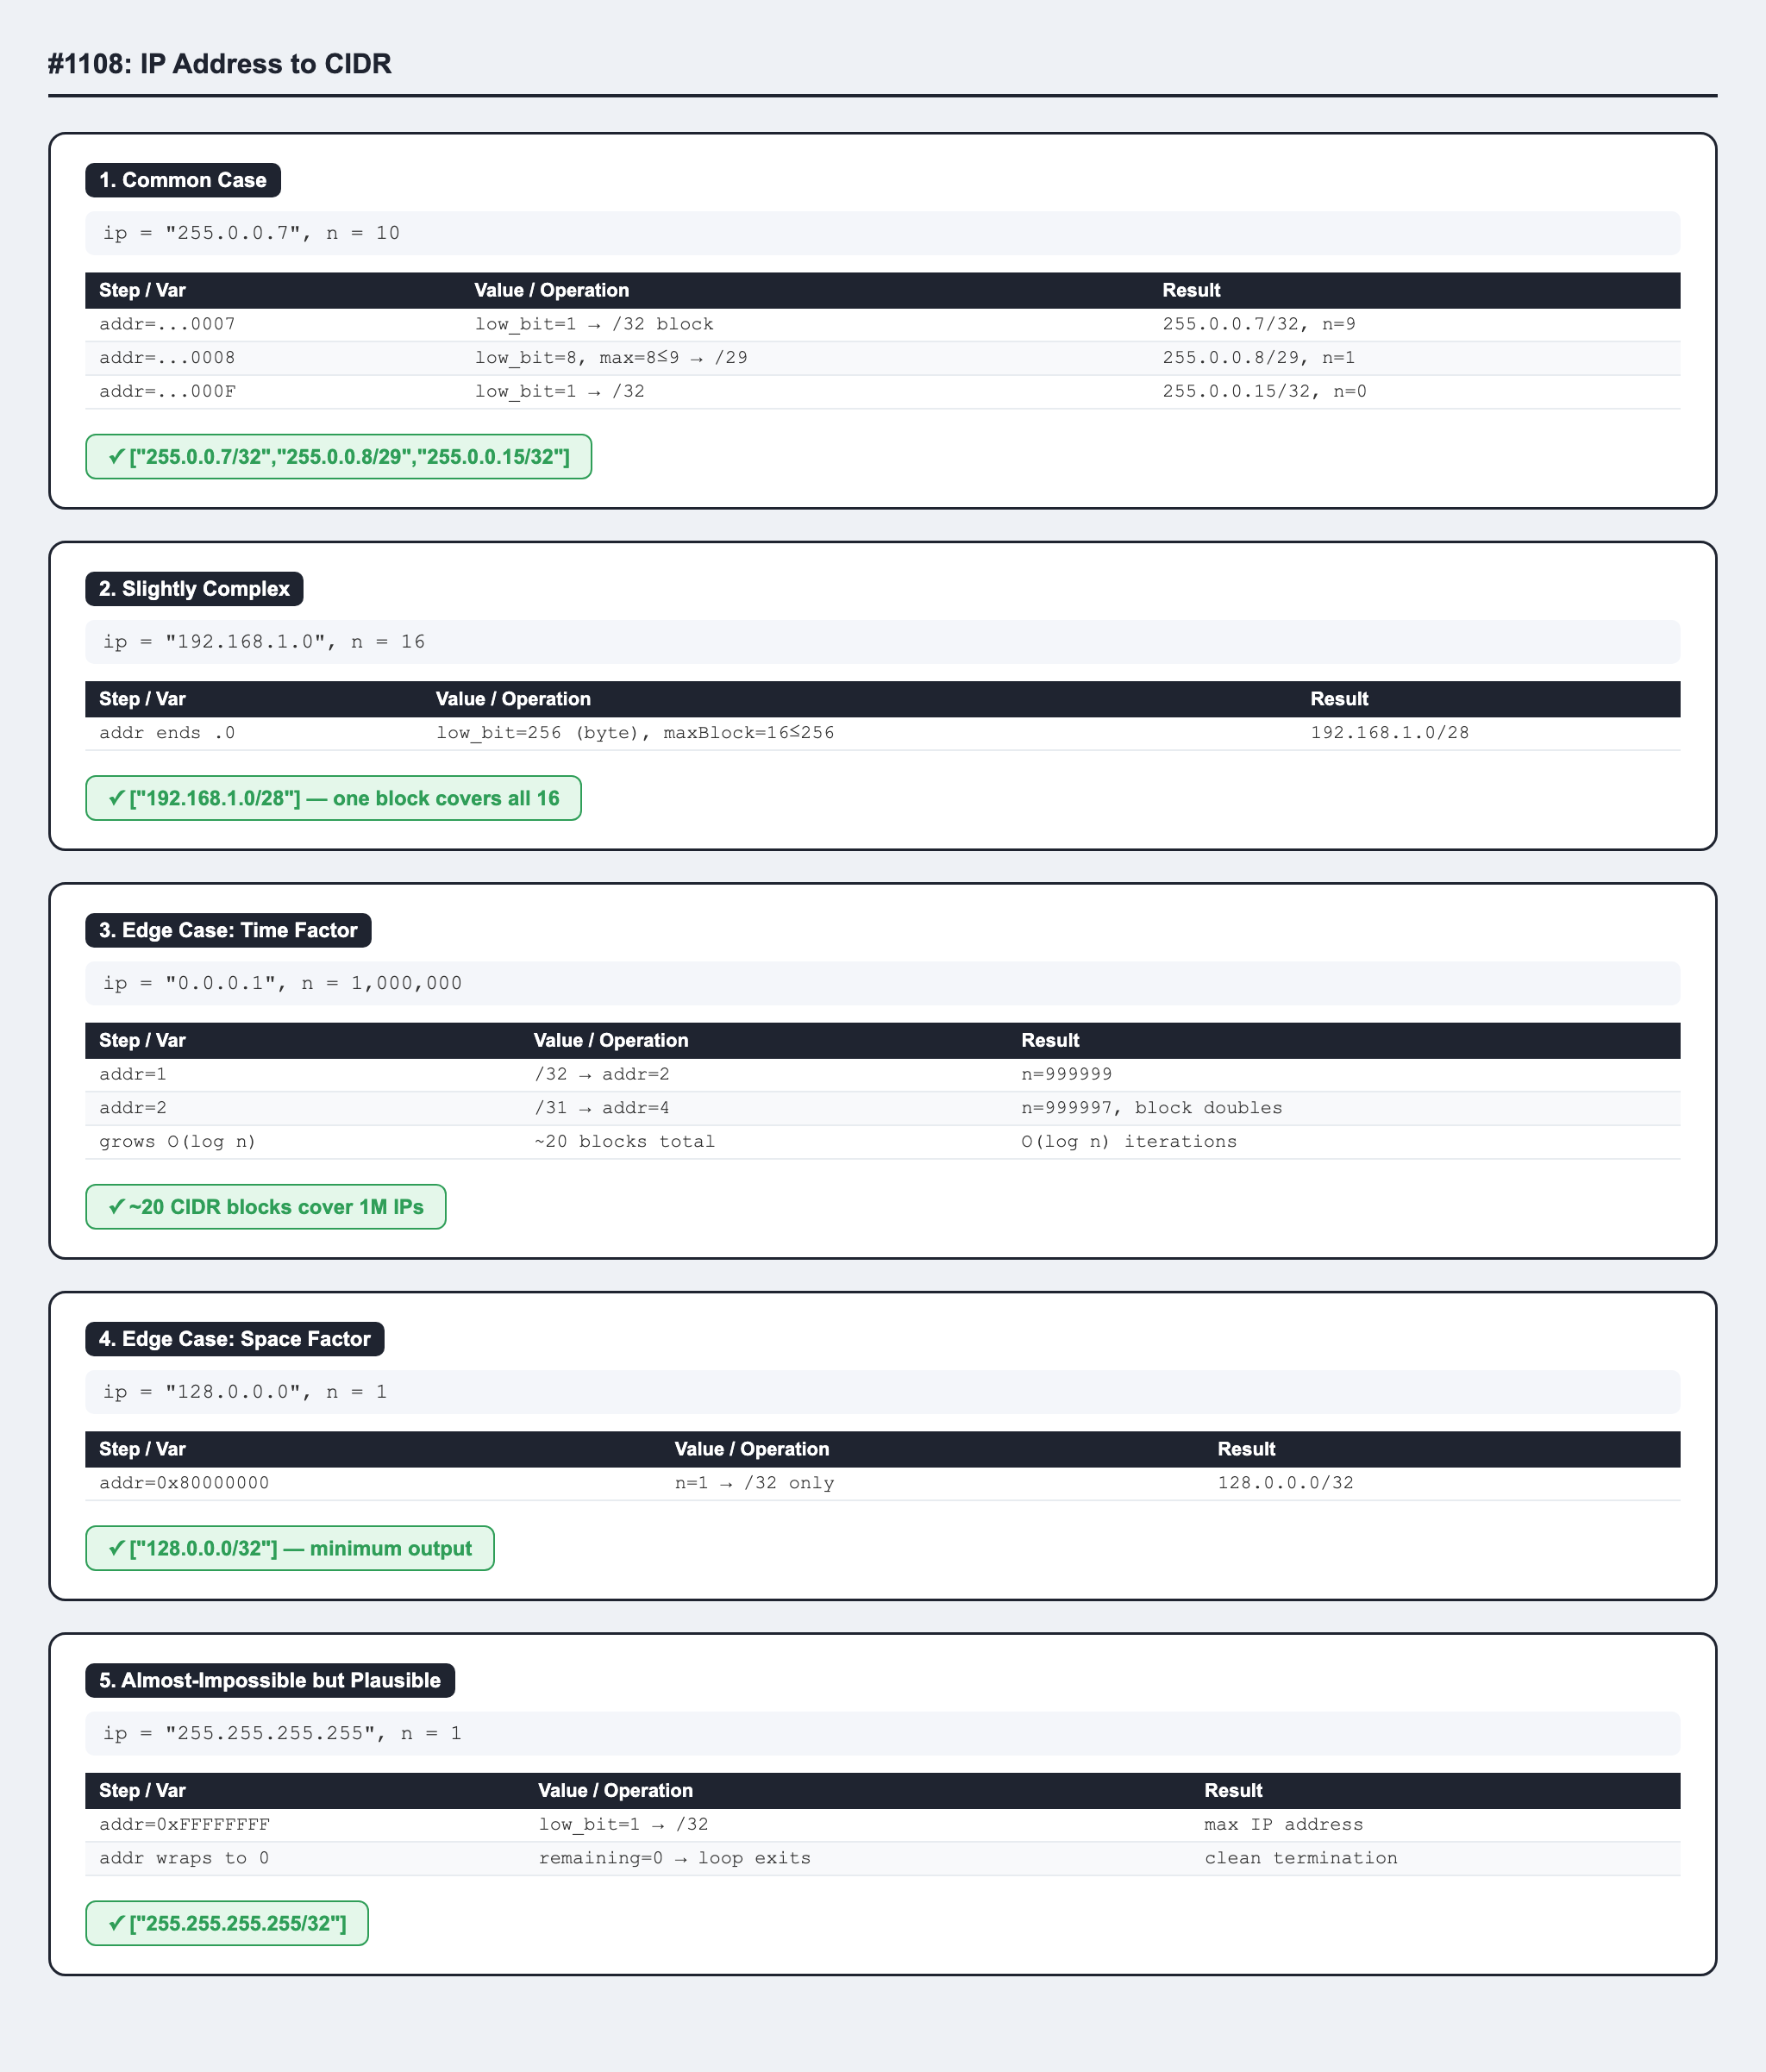